# Multi-species LSTM vs. single-species LSTMs — broad species mix

**Question.** Do LSTMs trained on pooled multi-species data with a species
context vector (one-hot or phylogenetic) outperform single-species LSTMs
trained on one species at a time — *especially* for species whose own
dataset is too small to train a reliable LSTM on its own?

**Species.**

| Region | Dataset | Target key | Species |
|---|---|---|---|
| W. Europe | `PEP725_Apple` | `BBCH_60` | *Malus × domestica* |
| W. Europe | `PEP725_Pear` | `BBCH_60` | *Pyrus communis* |
| W. Europe | `PEP725_Peach` | `BBCH_60` | *Prunus persica* |
| W. Europe | `PEP725_Almond` | `BBCH_60` | *Prunus amygdalis* |
| W. Europe | `PEP725_Cherry` | `BBCH_60` | *Prunus avium* |
| W. Europe | `PEP725_Apricot` | `BBCH_60` | *Prunus armeniaca* |
| W. Europe | `PEP725_Plum` | `BBCH_60` | *Prunus domestica* |

**Splits.** Temporal: years `< CUTOFF` for training, years `≥ CUTOFF` for
test. The multi-species training set is the union of the per-species
training splits; every model is evaluated on the *same* per-species test
splits so numbers are directly comparable.

**Small-sample regime.** A single-species LSTM is trained for *every* species,
including small ones. The bar chart shows training set sizes so you can judge
how sample count relates to single- vs. pooled-model performance.

**Caching.** Every trained model is saved to
`outputs/models/<name>/<name>.pt` and auto-loaded on subsequent runs.
Set `RETRAIN = True` to force re-training.

In [30]:
# ── Config ───────────────────────────────────────────────────────────────
RETRAIN = True                     # True → retrain every model
CUTOFF  = 2006                      # years < CUTOFF → train, ≥ CUTOFF → test
DATASETS_CONFIG = {
    # label        registry key           target key         scientific name
    'Apple':   dict(key='PEP725_Apple',   obs_key='BBCH_60', name='Malus x domestica'),
    'Pear':    dict(key='PEP725_Pear',    obs_key='BBCH_60', name='Pyrus communis'),
    'Peach':   dict(key='PEP725_Peach',   obs_key='BBCH_60', name='Prunus persica'),
    'Almond':  dict(key='PEP725_Almond',  obs_key='BBCH_60', name='Prunus amygdalis'),
    'Cherry':  dict(key='PEP725_Cherry',  obs_key='BBCH_60', name='Prunus avium'),
    'Apricot': dict(key='PEP725_Apricot', obs_key='BBCH_60', name='Prunus armeniaca'),
    'Plum':    dict(key='PEP725_Plum',    obs_key='BBCH_60', name='Prunus domestica'),
}

DATA_KEYS = ['temperature_2m_mean', 'daylight_duration']
PHYLO_K_EMBED = len(DATASETS_CONFIG)  # one dimension per species

MODEL_KWARGS = dict(
    data_keys   = DATA_KEYS,
    hidden_size = 64,
    num_layers  = 2,
)
TRAIN_KWARGS = dict(
    num_epochs               = 100,
    batch_size               = 32,
    val_period               = 10,
    optimizer                = 'adam',
    optimizer_kwargs         = dict(lr=1e-3, weight_decay=1e-4),
    scheduler_step_size      = 20,   # decay at 20/40/60/80/100
    scheduler_decay          = 0.5,  # stronger decay; fewer total steps
    early_stopping           = True,
    early_stopping_patience  = 25,  # 25% of budget
    early_stopping_min_delta = 1e-4,  # less aggressive threshold
    early_stopping_rerun     = False,   # skipped — doubles training time
    seed                     = 0,
    verbose                  = True,
)

In [31]:
import warnings
warnings.filterwarnings('ignore')

from functools import reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from pysephone.dataset.dataset import Dataset
from pysephone.dataset.observations import Observations
from pysephone.dataset.util.calendar import Calendar
from pysephone.dataset.util.openmeteo import OpenMeteoFeatures
from pysephone.dataset.util.phylogeny import PhylogenyFeatures
from pysephone.models.lstm import LSTMModel
from pysephone.models.lstm_ctx import (
    OneHotSpeciesLSTMModel,
    PhylogeneticLSTMModel,
)
from pysephone.paths import get_data_root, get_model_dir

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

device: cuda


## 1. Load every dataset

All datasets use `BBCH_60` as the target observation key.
PEP725 sources carry scientific names, which are used by the phylogeny fitter.

In [32]:
def target_fn(sample):
    return sample['observations']['BBCH_60']


cal = Calendar()

from pysephone.dataset.util.feature_cache import FeatureCache

per_species_trn: dict[str, Dataset] = {}
per_species_tst: dict[str, Dataset] = {}

for label, cfg in DATASETS_CONFIG.items():
    cache = FeatureCache.load(FeatureCache.default_path(cfg['key'], DATA_KEYS))
    ds    = Dataset.load(cfg['key'], calendar=cal, feature_providers=[cache])
    ys_trn = [y for y in ds.years if y <  CUTOFF]
    ys_tst = [y for y in ds.years if y >= CUTOFF]
    per_species_trn[label] = ds.select_years(ys_trn)
    per_species_tst[label] = ds.select_years(ys_tst)
    print(f'{label}: train={len(per_species_trn[label])}  test={len(per_species_tst[label])}')


Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 47597.27it/s]


Apple: train=4154  test=2607


Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 43340.39it/s]


Pear: train=979  test=2305


Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 43309.53it/s]


...

Cherry: train=4768  test=2797


Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 42290.60it/s]


Apricot: train=15  test=175


Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 46134.96it/s]


Plum: train=2420  test=684


In [33]:
# Sample-count summary
rows = []
for label in DATASETS_CONFIG:
    rows.append({
        'label':    label,
        'registry': DATASETS_CONFIG[label]['key'],
        'train_n':  len(per_species_trn[label]),
        'test_n':   len(per_species_tst[label]),
    })
display(pd.DataFrame(rows).set_index('label'))

SPECIES_FOR_SINGLE = list(DATASETS_CONFIG.keys())
print(f'Training single-species LSTMs for all species: {SPECIES_FOR_SINGLE}')

,registry,train_n,test_n
label,,,
Apple,PEP725_Apple,4154,2607
Pear,PEP725_Pear,979,2305
Peach,PEP725_Peach,979,14
Almond,PEP725_Almond,97,56
Cherry,PEP725_Cherry,4768,2797
Apricot,PEP725_Apricot,15,175
Plum,PEP725_Plum,2420,684


Training single-species LSTMs for all species: ['Apple', 'Pear', 'Peach', 'Almond', 'Cherry', 'Apricot', 'Plum']


In [34]:
# Pooled training set: union of every per-species training split
pooled_obs_trn = reduce(
    Observations.merge,
    [per_species_trn[l]._obs for l in DATASETS_CONFIG],
)

# PEP725_fruit_trees cache covers all species in the pooled set
_pool_cache = FeatureCache.load(FeatureCache.default_path('PEP725_fruit_trees', DATA_KEYS))
ds_pool_trn = Dataset(pooled_obs_trn, calendar=cal, feature_providers=[_pool_cache])

print(f'Pooled training set: {len(ds_pool_trn)} samples, '
      f'{len(pooled_obs_trn.species_names)} (src, species_id) pairs known')
print('Species names present for phylogeny:')
for k, v in sorted(pooled_obs_trn.species_names.items()):
    print(f'  {k}  →  {v}')


Pooled training set: 13412 samples, 7 (src, species_id) pairs known
Species names present for phylogeny:
  ('pep725', 202)  →  Prunus persica
  ('pep725', 205)  →  Prunus armeniaca
  ('pep725', 220)  →  Malus x domestica
  ('pep725', 222)  →  Prunus avium
  ('pep725', 225)  →  Prunus domestica
  ('pep725', 227)  →  Pyrus communis
  ('pep725', 782)  →  Prunus amygdalis


## 2. Fit the phylogenetic embedding (one OpenTree call)

In [35]:
phylo = PhylogenyFeatures(k_embed=PHYLO_K_EMBED, output=['mds']).fit(pooled_obs_trn)
species_keys = list(phylo.species_keys)
print(f'species_keys  ({len(species_keys)} pairs):')
for k in species_keys:
    print(f'  {k}')
print(f'mds_coords shape: {phylo.mds_coords.shape}')

species_keys  (7 pairs):
  ('pep725', 202)
  ('pep725', 205)
  ('pep725', 220)
  ('pep725', 222)
  ('pep725', 225)
  ('pep725', 227)
  ('pep725', 782)
mds_coords shape: (7, 6)


## 3. Train / load helper

Every model is saved to `outputs/models/<name>/<name>.pt`. A later run
reloads instantly unless `RETRAIN=True`.

In [36]:
def train_or_load(model_name, model_cls, model_kwargs, dataset, retrain=False):
    path = get_model_dir(get_data_root(), model_name) / f'{model_name}.pt'
    if not retrain and path.exists():
        model = torch.load(path, weights_only=False, map_location=DEVICE)
        model.eval()
        print(f'[loaded]   {model_name}')
        return model, None

    print(f'[training] {model_name}  (n={len(dataset)}) ...')
    model, info = model_cls.fit(
        target_fn    = target_fn,
        dataset      = dataset,
        model_kwargs = model_kwargs,
        device       = DEVICE,
        **TRAIN_KWARGS,
    )
    model.save(model_name)
    model.eval()
    print(f'[saved]    {model_name}')
    return model, info

## 4. Train the ensemble

| name | class | training data | context |
|---|---|---|---|
| `lstm_single_<label>` | `LSTMModel` | that species only | — |
| `lstm_pool_plain` | `LSTMModel` | pooled (7 datasets) | — |
| `lstm_pool_onehot` | `OneHotSpeciesLSTMModel` | pooled | one-hot |
| `lstm_pool_phylo` | `PhylogeneticLSTMModel` | pooled | phylogeny MDS |

In [37]:
models: dict = {}

# 4a. Single-species LSTMs — only where we have enough training samples
for label in SPECIES_FOR_SINGLE:
    name = f'lstm_single_{label}'
    models[name], _ = train_or_load(
        model_name   = name,
        model_cls    = LSTMModel,
        model_kwargs = dict(MODEL_KWARGS),
        dataset      = per_species_trn[label],
        retrain      = RETRAIN,
    )

[training] lstm_single_Apple  (n=4154) ...


LSTMModel epoch [    1/100] lr=1.00e-03 loss=0.25485: 100%|██████████| 97/97 [00:00<00:00, 231.31it/s]
LSTMModel epoch [    2/100] lr=1.00e-03 loss=0.04366: 100%|██████████| 97/97 [00:00<00:00, 231.59it/s]
LSTMModel epoch [    3/100] lr=1.00e-03 loss=0.03586: 100%|██████████| 97/97 [00:00<00:00, 221.93it/s]
LSTMModel epoch [    4/100] lr=1.00e-03 loss=0.03071: 100%|██████████| 97/97 [00:00<00:00, 207.82it/s]
LSTMModel epoch [    5/100] lr=1.00e-03 loss=0.03029: 100%|██████████| 97/97 [00:00<00:00, 217.81it/s]
LSTMModel epoch [    6/100] lr=1.00e-03 loss=0.02954: 100%|██████████| 97/97 [00:00<00:00, 215.56it/s]
LSTMModel epoch [    7/100] lr=1.00e-03 loss=0.02824: 100%|██████████| 97/97 [00:00<00:00, 213.74it/s]
LSTMModel epoch [    8/100] lr=1.00e-03 loss=0.02776: 100%|██████████| 97/97 [00:00<00:00, 228.46it/s]
LSTMModel epoch [    9/100] lr=1.00e-03 loss=0.02759: 100%|██████████| 97/97 [00:00<00:00, 226.69it/s]
LSTMModel epoch [   10/100] lr=1.00e-03 loss=0.02812: 100%|██████████| 97

[saved]    lstm_single_Apple
[training] lstm_single_Pear  (n=979) ...


LSTMModel epoch [    1/100] lr=1.00e-03 loss=0.66136: 100%|██████████| 19/19 [00:00<00:00, 204.73it/s]
LSTMModel epoch [    2/100] lr=1.00e-03 loss=0.39966: 100%|██████████| 19/19 [00:00<00:00, 238.55it/s]
LSTMModel epoch [    3/100] lr=1.00e-03 loss=0.12694: 100%|██████████| 19/19 [00:00<00:00, 238.26it/s]
LSTMModel epoch [    4/100] lr=1.00e-03 loss=0.06231: 100%|██████████| 19/19 [00:00<00:00, 226.73it/s]
LSTMModel epoch [    5/100] lr=1.00e-03 loss=0.04640: 100%|██████████| 19/19 [00:00<00:00, 215.11it/s]
LSTMModel epoch [    6/100] lr=1.00e-03 loss=0.04095: 100%|██████████| 19/19 [00:00<00:00, 222.01it/s]
LSTMModel epoch [    7/100] lr=1.00e-03 loss=0.03860: 100%|██████████| 19/19 [00:00<00:00, 238.33it/s]
LSTMModel epoch [    8/100] lr=1.00e-03 loss=0.03689: 100%|██████████| 19/19 [00:00<00:00, 228.88it/s]
LSTMModel epoch [    9/100] lr=1.00e-03 loss=0.03628: 100%|██████████| 19/19 [00:00<00:00, 215.49it/s]
LSTMModel epoch [   10/100] lr=1.00e-03 loss=0.03740: 100%|██████████| 19

[saved]    lstm_single_Pear
[training] lstm_single_Peach  (n=979) ...


...

[saved]    lstm_single_Cherry
[training] lstm_single_Apricot  (n=15) ...


LSTMModel epoch [    1/100] lr=1.00e-03 loss=0.69218: 100%|██████████| 1/1 [00:00<00:00, 225.77it/s]
LSTMModel epoch [    2/100] lr=1.00e-03 loss=0.68968: 100%|██████████| 1/1 [00:00<00:00, 267.00it/s]
LSTMModel epoch [    3/100] lr=1.00e-03 loss=0.68719: 100%|██████████| 1/1 [00:00<00:00, 291.35it/s]
LSTMModel epoch [    4/100] lr=1.00e-03 loss=0.68467: 100%|██████████| 1/1 [00:00<00:00, 315.96it/s]
LSTMModel epoch [    5/100] lr=1.00e-03 loss=0.68205: 100%|██████████| 1/1 [00:00<00:00, 316.24it/s]
LSTMModel epoch [    6/100] lr=1.00e-03 loss=0.67929: 100%|██████████| 1/1 [00:00<00:00, 306.04it/s]
LSTMModel epoch [    7/100] lr=1.00e-03 loss=0.67634: 100%|██████████| 1/1 [00:00<00:00, 346.75it/s]
LSTMModel epoch [    8/100] lr=1.00e-03 loss=0.67310: 100%|██████████| 1/1 [00:00<00:00, 244.05it/s]
LSTMModel epoch [    9/100] lr=1.00e-03 loss=0.66943: 100%|██████████| 1/1 [00:00<00:00, 256.16it/s]
LSTMModel epoch [   10/100] lr=1.00e-03 loss=0.66534: 100%|██████████| 1/1 [00:00<00:00, 26

[saved]    lstm_single_Apricot
[training] lstm_single_Plum  (n=2420) ...


LSTMModel epoch [    1/100] lr=1.00e-03 loss=0.37629: 100%|██████████| 58/58 [00:00<00:00, 228.33it/s]
LSTMModel epoch [    2/100] lr=1.00e-03 loss=0.06744: 100%|██████████| 58/58 [00:00<00:00, 248.89it/s]
LSTMModel epoch [    3/100] lr=1.00e-03 loss=0.04901: 100%|██████████| 58/58 [00:00<00:00, 234.39it/s]
LSTMModel epoch [    4/100] lr=1.00e-03 loss=0.04196: 100%|██████████| 58/58 [00:00<00:00, 251.15it/s]
LSTMModel epoch [    5/100] lr=1.00e-03 loss=0.04116: 100%|██████████| 58/58 [00:00<00:00, 240.71it/s]
LSTMModel epoch [    6/100] lr=1.00e-03 loss=0.03877: 100%|██████████| 58/58 [00:00<00:00, 241.60it/s]
LSTMModel epoch [    7/100] lr=1.00e-03 loss=0.03826: 100%|██████████| 58/58 [00:00<00:00, 229.78it/s]
LSTMModel epoch [    8/100] lr=1.00e-03 loss=0.03653: 100%|██████████| 58/58 [00:00<00:00, 199.16it/s]
LSTMModel epoch [    9/100] lr=1.00e-03 loss=0.03732: 100%|██████████| 58/58 [00:00<00:00, 215.05it/s]
LSTMModel epoch [   10/100] lr=1.00e-03 loss=0.03551: 100%|██████████| 58

[saved]    lstm_single_Plum


In [38]:
# 4b. Pooled LSTM, no species info  (sanity baseline)
models['lstm_pool_plain'], _ = train_or_load(
    model_name   = 'lstm_pool_plain',
    model_cls    = LSTMModel,
    model_kwargs = dict(MODEL_KWARGS),
    dataset      = ds_pool_trn,
    retrain      = RETRAIN,
)

# 4c. Pooled LSTM + one-hot species context
models['lstm_pool_onehot'], _ = train_or_load(
    model_name   = 'lstm_pool_onehot',
    model_cls    = OneHotSpeciesLSTMModel,
    model_kwargs = dict(MODEL_KWARGS, species_keys=species_keys),
    dataset      = ds_pool_trn,
    retrain      = RETRAIN,
)

# 4d. Pooled LSTM + phylogenetic MDS context
models['lstm_pool_phylo'], _ = train_or_load(
    model_name   = 'lstm_pool_phylo',
    model_cls    = PhylogeneticLSTMModel,
    model_kwargs = dict(MODEL_KWARGS,
                        species_keys=species_keys,
                        mds_coords=phylo.mds_coords),
    dataset      = ds_pool_trn,
    retrain      = RETRAIN,
)

[training] lstm_pool_plain  (n=13412) ...


LSTMModel epoch [    1/100] lr=1.00e-03 loss=0.11507: 100%|██████████| 311/311 [00:01<00:00, 231.87it/s]
LSTMModel epoch [    2/100] lr=1.00e-03 loss=0.04851: 100%|██████████| 311/311 [00:01<00:00, 241.36it/s]
LSTMModel epoch [    3/100] lr=1.00e-03 loss=0.04822: 100%|██████████| 311/311 [00:01<00:00, 240.27it/s]
LSTMModel epoch [    4/100] lr=1.00e-03 loss=0.04703: 100%|██████████| 311/311 [00:01<00:00, 233.62it/s]
LSTMModel epoch [    5/100] lr=1.00e-03 loss=0.04741: 100%|██████████| 311/311 [00:01<00:00, 239.37it/s]
LSTMModel epoch [    6/100] lr=1.00e-03 loss=0.04618: 100%|██████████| 311/311 [00:01<00:00, 244.43it/s]
LSTMModel epoch [    7/100] lr=1.00e-03 loss=0.04575: 100%|██████████| 311/311 [00:01<00:00, 242.27it/s]
LSTMModel epoch [    8/100] lr=1.00e-03 loss=0.04577: 100%|██████████| 311/311 [00:01<00:00, 235.10it/s]
LSTMModel epoch [    9/100] lr=1.00e-03 loss=0.04519: 100%|██████████| 311/311 [00:01<00:00, 237.77it/s]
LSTMModel epoch [   10/100] lr=1.00e-03 loss=0.04566: 1

[saved]    lstm_pool_plain
[training] lstm_pool_onehot  (n=13412) ...


OneHotSpeciesLSTMModel epoch [    1/100] lr=1.00e-03 loss=0.11200: 100%|██████████| 311/311 [00:02<00:00, 132.57it/s]
OneHotSpeciesLSTMModel epoch [    2/100] lr=1.00e-03 loss=0.03791: 100%|██████████| 311/311 [00:02<00:00, 133.78it/s]
OneHotSpeciesLSTMModel epoch [    3/100] lr=1.00e-03 loss=0.03514: 100%|██████████| 311/311 [00:02<00:00, 134.40it/s]
OneHotSpeciesLSTMModel epoch [    4/100] lr=1.00e-03 loss=0.03320: 100%|██████████| 311/311 [00:02<00:00, 135.85it/s]
OneHotSpeciesLSTMModel epoch [    5/100] lr=1.00e-03 loss=0.03238: 100%|██████████| 311/311 [00:02<00:00, 130.90it/s]
OneHotSpeciesLSTMModel epoch [    6/100] lr=1.00e-03 loss=0.03142: 100%|██████████| 311/311 [00:02<00:00, 144.87it/s]
OneHotSpeciesLSTMModel epoch [    7/100] lr=1.00e-03 loss=0.03107: 100%|██████████| 311/311 [00:02<00:00, 143.99it/s]
OneHotSpeciesLSTMModel epoch [    8/100] lr=1.00e-03 loss=0.03202: 100%|██████████| 311/311 [00:02<00:00, 128.34it/s]
OneHotSpeciesLSTMModel epoch [    9/100] lr=1.00e-03 los

[saved]    lstm_pool_onehot
[training] lstm_pool_phylo  (n=13412) ...


PhylogeneticLSTMModel epoch [    1/100] lr=1.00e-03 loss=0.11876: 100%|██████████| 311/311 [00:01<00:00, 266.93it/s]
PhylogeneticLSTMModel epoch [    2/100] lr=1.00e-03 loss=0.03749: 100%|██████████| 311/311 [00:01<00:00, 261.27it/s]
PhylogeneticLSTMModel epoch [    3/100] lr=1.00e-03 loss=0.03398: 100%|██████████| 311/311 [00:01<00:00, 273.85it/s]
PhylogeneticLSTMModel epoch [    4/100] lr=1.00e-03 loss=0.03280: 100%|██████████| 311/311 [00:01<00:00, 223.57it/s]
PhylogeneticLSTMModel epoch [    5/100] lr=1.00e-03 loss=0.03203: 100%|██████████| 311/311 [00:01<00:00, 212.83it/s]
PhylogeneticLSTMModel epoch [    6/100] lr=1.00e-03 loss=0.03113: 100%|██████████| 311/311 [00:01<00:00, 218.07it/s]
PhylogeneticLSTMModel epoch [    7/100] lr=1.00e-03 loss=0.03133: 100%|██████████| 311/311 [00:01<00:00, 217.86it/s]
PhylogeneticLSTMModel epoch [    8/100] lr=1.00e-03 loss=0.03087: 100%|██████████| 311/311 [00:01<00:00, 217.06it/s]
PhylogeneticLSTMModel epoch [    9/100] lr=1.00e-03 loss=0.03025

[saved]    lstm_pool_phylo


## 5. Evaluate every model on every per-species test split

Single-species models are only evaluated on their own species. The three
pooled models are evaluated on **all** species — including those whose own
dataset was too small to train a single-species LSTM on.

In [39]:
def evaluate(model, dataset, target_fn, device=torch.device('cpu')):
    if hasattr(model, 'to'):
        model.to(device)
    errors, ys_true, ys_pred = [], [], []
    for sample in dataset.iter_items():
        try:
            target_date = target_fn(sample)
        except KeyError:
            continue
        pred_date, _ = model.predict(sample, device=device)
        season_start = np.datetime64(sample['season_start'], 'D')
        t_ix = int((np.datetime64(target_date, 'D') - season_start) / np.timedelta64(1, 'D'))
        p_ix = int((np.datetime64(pred_date,   'D') - season_start) / np.timedelta64(1, 'D'))
        ys_true.append(t_ix); ys_pred.append(p_ix); errors.append(p_ix - t_ix)
    if not errors:
        return None
    e = np.array(errors, dtype=float)
    return {
        'n':    len(e),
        'MAE':  float(np.abs(e).mean()),
        'RMSE': float(np.sqrt((e**2).mean())),
        'bias': float(e.mean()),
        'ys_true': np.array(ys_true), 'ys_pred': np.array(ys_pred),
    }


rows = []
eval_cache: dict = {}
for model_name, model in models.items():
    for species_label, ds_tst in per_species_tst.items():
        if model_name.startswith('lstm_single_') and model_name != f'lstm_single_{species_label}':
            continue
        if len(ds_tst) == 0:
            continue
        m = evaluate(model, ds_tst, target_fn, device=DEVICE)
        if m is None:
            continue
        eval_cache[(model_name, species_label)] = m
        rows.append({
            'model':   model_name,
            'species': species_label,
            'n':       m['n'],
            'MAE':     round(m['MAE'],  2),
            'RMSE':    round(m['RMSE'], 2),
            'bias':    round(m['bias'], 2),
        })
df = pd.DataFrame(rows)
display(df)

,model,species,n,MAE,RMSE,bias
0,lstm_single_Apple,Apple,2607,3.78,5.10,0.67
1,lstm_single_Pear,Pear,2305,4.74,6.28,2.90
2,lstm_single_Peach,Peach,14,6.64,7.29,2.79
3,lstm_single_Almond,Almond,56,11.66,13.67,-3.30
4,lstm_single_Cherry,Cherry,2797,4.07,5.61,0.20
5,lstm_single_Apricot,Apricot,175,13.02,15.71,11.23
6,lstm_single_Plum,Plum,684,5.77,7.88,0.50
7,lstm_pool_plain,Apple,2607,5.96,7.67,-4.83
8,lstm_pool_plain,Pear,2305,5.05,6.52,1.43
9,lstm_pool_plain,Peach,14,15.86,18.27,10.57


In [40]:
# ── Per-species MAE table ────────────────────────────────────────────────────
# Normalise model names: collapse lstm_single_<X> → 'single' for species X's own model.
df_tbl = df.copy()
df_tbl['model'] = df_tbl.apply(
    lambda r: 'single' if r['model'] == f'lstm_single_{r["species"]}' else r['model'],
    axis=1,
)
# Drop off-diagonal single-species rows (other species' single models evaluated here)
df_tbl = df_tbl[~df_tbl['model'].str.startswith('lstm_single_')]

pivot = df_tbl.pivot(index='species', columns='model', values='MAE')
pivot = pivot.reindex(
    columns=[c for c in ['single', 'lstm_pool_plain', 'lstm_pool_onehot', 'lstm_pool_phylo']
             if c in pivot.columns],
    index=list(DATASETS_CONFIG.keys()),
)
display(pivot.round(2))

# ── Δ MAE vs single-species LSTM ─────────────────────────────────────────────
print('\nΔ MAE vs. single-species LSTM  (negative = pooled model is better).')
summary_rows = []
for s in DATASETS_CONFIG:
    has_single = 'single' in pivot.columns and not np.isnan(pivot.loc[s, 'single'])
    row = {
        'species':  s,
        'train_n':  len(per_species_trn[s]),
        'single':   round(float(pivot.loc[s, 'single']), 2) if has_single else np.nan,
    }
    for pool in ['lstm_pool_plain', 'lstm_pool_onehot', 'lstm_pool_phylo']:
        if pool not in pivot.columns or np.isnan(pivot.loc[s, pool]):
            row[pool] = np.nan
            continue
        pool_mae = float(pivot.loc[s, pool])
        if has_single:
            delta = pool_mae - float(pivot.loc[s, 'single'])
            row[pool] = f'{pool_mae:.2f}  ({delta:+.2f})'
        else:
            row[pool] = f'{pool_mae:.2f}'
    summary_rows.append(row)
display(pd.DataFrame(summary_rows).set_index('species'))

model,single,lstm_pool_plain,lstm_pool_onehot,lstm_pool_phylo
species,,,,
Apple,3.78,5.96,3.72,3.84
Pear,4.74,5.05,5.55,6.42
Peach,6.64,15.86,5.79,8.36
Almond,11.66,49.38,11.79,11.61
Cherry,4.07,6.38,4.29,4.58
Apricot,13.02,15.77,10.01,9.67
Plum,5.77,6.02,5.90,6.15



Δ MAE vs. single-species LSTM  (negative = pooled model is better).


,train_n,single,lstm_pool_plain,lstm_pool_onehot,lstm_pool_phylo
species,,,,,
Apple,4154,3.78,5.96 (+2.18),3.72 (-0.06),3.84 (+0.06)
Pear,979,4.74,5.05 (+0.31),5.55 (+0.81),6.42 (+1.68)
Peach,979,6.64,15.86 (+9.22),5.79 (-0.85),8.36 (+1.72)
Almond,97,11.66,49.38 (+37.72),11.79 (+0.13),11.61 (-0.05)
Cherry,4768,4.07,6.38 (+2.31),4.29 (+0.22),4.58 (+0.51)
Apricot,15,13.02,15.77 (+2.75),10.01 (-3.01),9.67 (-3.35)
Plum,2420,5.77,6.02 (+0.25),5.90 (+0.13),6.15 (+0.38)


## 6. Visualisations

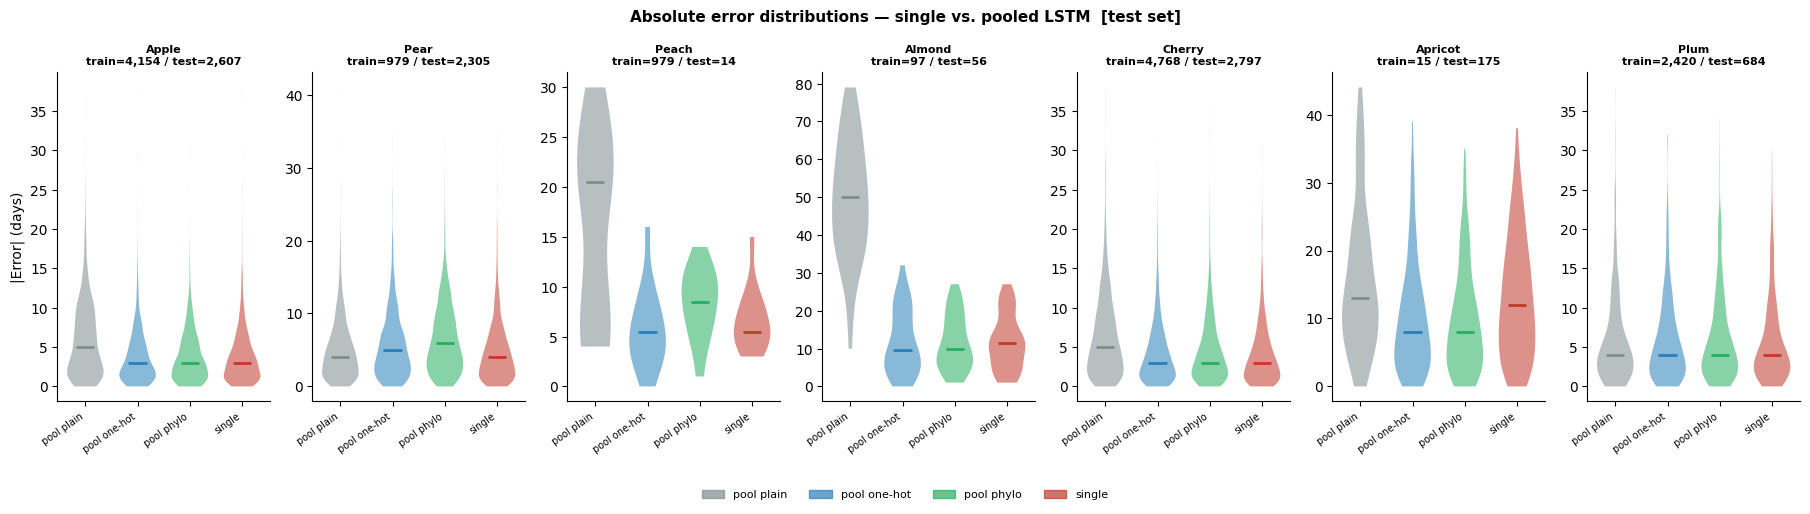

In [41]:
# ── Violin + strip plot: per-species error distributions by model ─────────────
# Each panel is one species. Within each panel, one violin per model shows the
# full distribution of (predicted - observed) errors on the test set.
# X-tick labels carry both train and test sample counts.

MODEL_ORDER_PLOT = ['lstm_pool_plain', 'lstm_pool_onehot', 'lstm_pool_phylo',
                    'lstm_single_{species}']
MODEL_COLORS     = {
    'lstm_pool_plain':       '#7f8c8d',
    'lstm_pool_onehot':      '#2980b9',
    'lstm_pool_phylo':       '#27ae60',
    'lstm_single_{species}': '#c0392b',
}
MODEL_LABELS = {
    'lstm_pool_plain':       'pool plain',
    'lstm_pool_onehot':      'pool one-hot',
    'lstm_pool_phylo':       'pool phylo',
    'lstm_single_{species}': 'single',
}

labels    = list(DATASETS_CONFIG.keys())
n_species = len(labels)
n_models  = len(MODEL_ORDER_PLOT)

fig, axes = plt.subplots(1, n_species, figsize=(2.6 * n_species, 5), sharey=False)
fig.suptitle('Absolute error distributions — single vs. pooled LSTM  [test set]',
             fontweight='bold', fontsize=11)

for ax, sp in zip(axes, labels):
    pos = np.arange(n_models)
    vdata = []
    colors = []

    for tmpl in MODEL_ORDER_PLOT:
        name = tmpl.replace('{species}', sp)
        key  = (name, sp)
        if key in eval_cache:
            m = eval_cache[key]
            errs = np.abs(m['ys_pred'] - m['ys_true']).astype(float)
        else:
            errs = np.array([np.nan])
        vdata.append(errs)
        colors.append(MODEL_COLORS[tmpl])

    # Violin plots (skip where data is effectively missing)
    for i, (errs, col) in enumerate(zip(vdata, colors)):
        valid = errs[~np.isnan(errs)]
        if len(valid) < 2:
            ax.text(i, 0, 'n/a', ha='center', va='center', fontsize=7, color='grey')
            continue
        vp = ax.violinplot(valid, positions=[i], widths=0.7,
                           showmedians=True, showextrema=False)
        for pc in vp['bodies']:
            pc.set_facecolor(col); pc.set_alpha(0.55); pc.set_edgecolor('none')
        vp['cmedians'].set_color(col); vp['cmedians'].set_linewidth(2)

    ax.set_xticks(pos)
    ax.set_xticklabels([MODEL_LABELS[t] for t in MODEL_ORDER_PLOT],
                       rotation=35, ha='right', fontsize=7)
    n_trn = len(per_species_trn[sp])
    n_tst = len(per_species_tst[sp])
    ax.set_title(f'{sp}\ntrain={n_trn:,} / test={n_tst:,}', fontsize=8, fontweight='bold')
    ax.set_ylabel('|Error| (days)' if ax == axes[0] else '')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Shared legend
handles = [plt.Rectangle((0,0),1,1, color=MODEL_COLORS[t], alpha=0.7)
           for t in MODEL_ORDER_PLOT]
fig.legend(handles, [MODEL_LABELS[t] for t in MODEL_ORDER_PLOT],
           loc='lower center', ncol=4, fontsize=8, frameon=False,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

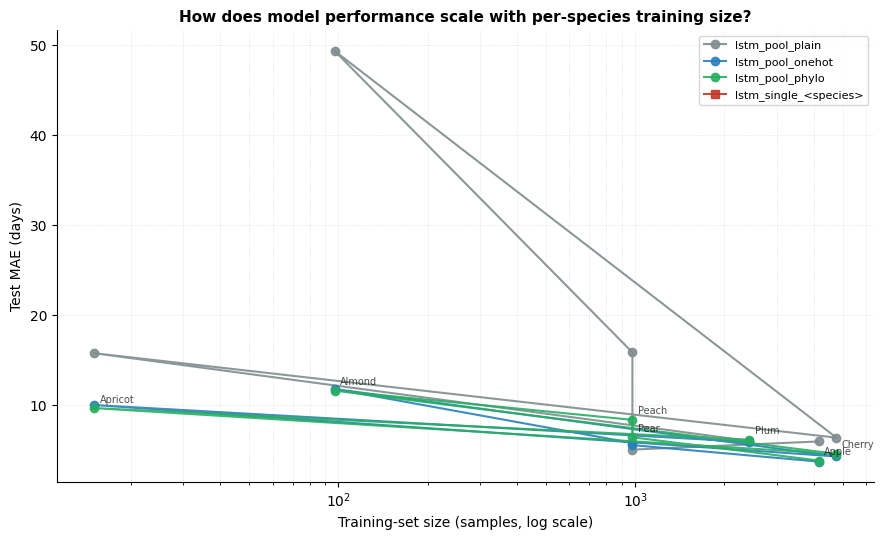

: 

In [ ]:
POOL_COLORS = {k: v for k, v in MODEL_COLORS.items() if k != 'lstm_single_{species}'}

# ── MAE vs training-set size — does species-context matter more for small datasets? ─
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.set_xscale('log')

sizes = np.array([len(per_species_trn[s]) for s in labels])
for name, color in POOL_COLORS.items():
    if name not in pivot.columns:
        continue
    maes = pivot[name].reindex(labels).values
    ax.plot(sizes, maes, marker='o', lw=1.5, color=color, label=name, alpha=0.9)

# Single LSTM only where it exists
mask = [f'lstm_single_{s}' in pivot.columns for s in labels]
s_sizes = sizes[mask]
s_maes  = [float(pivot.loc[s, f'lstm_single_{s}']) for s, m in zip(labels, mask) if m]
ax.plot(s_sizes, s_maes, marker='s', lw=1.5, color='#c0392b',
        label='lstm_single_<species>', alpha=0.9)

# Label each point with species name
for sp, size in zip(labels, sizes):
    if 'lstm_pool_phylo' in pivot.columns:
        y = pivot.loc[sp, 'lstm_pool_phylo']
        if not np.isnan(y):
            ax.annotate(sp, (size, y), fontsize=7, alpha=0.7,
                        xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('Training-set size (samples, log scale)')
ax.set_ylabel('Test MAE (days)')
ax.set_title('How does model performance scale with per-species training size?',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(True, which='both', ls=':', lw=0.5, alpha=0.5)
plt.tight_layout(); plt.show()

## 7. Interpretation checklist

- **Pooled beats single (all species)** → shared weather dynamics dominate; more
  data helps even without species labels.
- **Pooled beats single more for small species** (visible in the log-scale
  plot above) → pooled training rescues species with sparse data, which is
  the regime you asked about.
- **One-hot ≪ plain** → the model *can* use species identity when it's given.
- **Phylo ≈ one-hot** → relatedness adds nothing beyond identity in this
  closed set.  Phylo usually only wins when test species are rare (or absent)
  in training — consider a leave-one-species-out variant to probe that.
- **Phylo < one-hot for small species** → transferable structure kicks in
  exactly where one-hot can't generalise.